In [1]:
!wget https://lazyprogrammer.me/course_files/spam.csv

--2025-05-06 11:32:24--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  2.22MB/s    in 0.2s    

2025-05-06 11:32:25 (2.22 MB/s) - ‘spam.csv’ saved [503663/503663]



In [2]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

In [3]:
class Dataset:
    HAM = 0
    SPAM = 1

    def __init__(self, path: str):
        self._df = pd.read_csv(path, encoding="ISO-8859-1")
        self._df = self._clean_df(self._df)

        self._df = self._create_numeric_label(self._df)
    
    def _clean_df(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
        df.columns = ['labels', 'data']
        return df
    
    def _create_numeric_label(self, df: pd.DataFrame) -> pd.DataFrame:
        df["b_labels"] = df["labels"].apply(lambda x: self.HAM if x == "ham" else self.SPAM)
        return df

    @property
    def df(self) -> pd.DataFrame:
        return self._df

In [4]:
dataset = Dataset("../datasets/spam.csv")
X_train, X_test, Y_train, Y_test = train_test_split(dataset.df["data"], dataset.df["b_labels"], test_size=0.33)

In [ ]:
featurizer = CountVectorizer(decode_error='ignore')
Xtrain = featurizer.fit_transform(X_train)
Xtest = featurizer.transform(X_test)

In [ ]:
model = MultinomialNB()
model.fit(Xtrain, Y_train)

print("train acc:", model.score(Xtrain, Y_train))
print("test acc:", model.score(Xtest, Y_test))

Ptrain = model.predict(Xtrain)
Ptest = model.predict(Xtest)

print("train f1_score:", f1_score(Y_train, Ptrain))
print("test f1_score:", f1_score(Y_test, Ptest))

train acc: 0.994910259844629
test acc: 0.9815116911364872
train f1_score: 0.9812067260138477
test f1_score: 0.925764192139738


In [7]:
cm = confusion_matrix(Y_train, Ptrain)
cm

array([[3218,    8],
       [  11,  496]])

In [ ]:
def word_collage(label):
  words = ''
  for msg in dataset.df[dataset.df['labels'] == label]['data']:
    msg = msg.lower()
    words += msg + ' '

  wordcloud = WordCloud(width=600, height=400).generate(words)
  plt.imshow(wordcloud)
  plt.axis('off')
  plt.show()

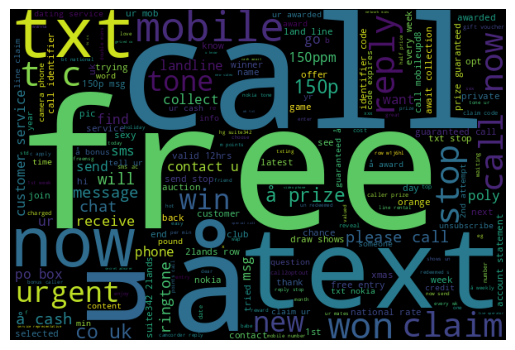

In [ ]:
word_collage("spam")

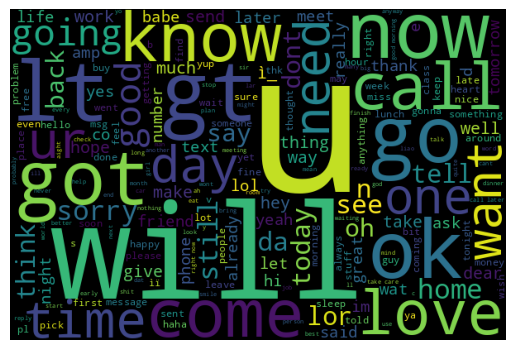

In [10]:
word_collage("ham")

In [13]:
x = featurizer.transform(dataset.df['data'])
dataset.df['predictions'] = model.predict(x)

sneaky_spam = dataset.df[(dataset.df['predictions'] == 0) & (dataset.df['b_labels'] == 1)]['data']
for msg in sneaky_spam:
  print(msg)

FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
Did you hear about the new \Divorce Barbie\"? It comes with all of Ken's stuff!"
Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?
Talk sexy!! Make new friends or fall in love in the worlds most discreet text dating service. Just text VIP to 83110 and see who you could meet.
Hello. We need some posh birds and chaps to user trial prods for champneys. Can i put you down? I need your address and dob asap. Ta r
Dont forget you can place as many FREE Requests with 1stchoice.co.uk as you wish. For more Information call 08707808226.
Please CALL 08712402779 immediately as there is an urgent message waiting for you
Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102316 U can cum here 2moro Luv JANE xx Callså£1/minmoremobsEMSPOBox45PO139WA
Hi its LUCY Hubby at meetins all day